In [16]:
from opfython.models import SupervisedOPF

import logging
from io import StringIO
from contextlib import redirect_stdout, redirect_stderr


In [17]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap
from joblib import Parallel, delayed
import logging
import sys
import warnings
import os
from contextlib import redirect_stdout, redirect_stderr

# Suppress all logging output
os.environ['OPF_LOG_LEVEL'] = 'ERROR'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS'] = 'ignore'

warnings.filterwarnings('ignore')

# Suppress all loggers - disable INFO and DEBUG
logging.getLogger().setLevel(logging.WARNING)
logging.disable(logging.INFO)

# Disable specific loggers
for logger_name in ['opfython', 'opfython.core', 'opfython.models', 'opfython.ml']:
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.WARNING)
    logger.disabled = True
    logger.propagate = False
    logger.handlers.clear()
    logger.addHandler(logging.NullHandler())

In [20]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')

df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())
unique_names_cacao = df_cacao['10101010.00'].unique()

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())


In [13]:
from sklearn.model_selection import KFold

def ICAFS(dataset_X, dataset_Y, strenght, max_iteartion, clasifier, print_logs=False):

  max_it = 1 
  std_list = []
 
  iter_list = []
  score_list = []

  featur_list = [] 
  v_variable = [0, 1]
  
  best_global_score = float('-inf')
  best_global_feattures = []

  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()


  _initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,clasifier)
  while max_iteartion_aux > 0:

      
      partial_score = 0
      dict_parameters = {}
      partial_best_list = []
      subsets_to_consider = []

      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for i, test in enumerate(generate_covering_array.array):
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          subsets_to_consider.append((list_attributes_to_consider, i))
      
      results = Parallel(n_jobs=-1,backend='loky')(delayed(_run_cv)(clasifier, dataset_X, subset_features, dataset_Y.values.ravel(), i) for subset_features,i in subsets_to_consider)   
      sorted_results = sorted(results, key=lambda x: x[2])
      
      for score, std, i, subset_features in sorted_results:
        if score >= partial_score:
              partial_score = score
              best_std = std
              partial_best_list = subset_features.copy()

      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )
      
      if best_f1_score >= best_global_score:
          best_global_score = best_f1_score
          best_global_feattures = best_data_set.copy()

      iter_list.append(max_it)
      aux_data_score = best_f1_score
      score_list.append(aux_data_score)

      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
      std_list.append(best_std)

  return iter_list, featur_list, score_list, std_list, best_global_feattures

def _initial_test_training(score_list, iter_list, feature_list ,X,y,clasifier):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     
     clasifier.fit(X_train_temp, y_train_temp)
     y_pred = clasifier.predict(X_test_temp)
     
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def _kfold_with_opf_in_icafs(clasifier, x_data, y_data):
    
    scores = []
    kf = KFold(n_splits=5,shuffle=True, random_state =42)
    for i, (train_index, test_index) in enumerate(kf.split(x_data)):
   
        x_fold_train = x_data[train_index,:]
        y_fold_train = y_data[train_index]

        x_fold_test =  x_data[test_index,:]
        y_fold_test = y_data[test_index]
        
        clasifier.fit(x_fold_train, y_fold_train)
        y_pred_fold = clasifier.predict(x_fold_test)
        score = f1_score(y_fold_test, y_pred_fold,average='macro')
        scores.append(score)

    return np.asarray(scores, dtype=np.float32)

def _run_cv(model, X, subset_features, y, index):

    null_file = StringIO()
    # Disable INFO and DEBUG logging temporarily
    logging.disable(logging.INFO)
    
    try:
        # Redirect both stdout and stderr to null
        with redirect_stdout(null_file), redirect_stderr(null_file):
            scores = _kfold_with_opf_in_icafs(model, X[subset_features].values, y)
        return (scores.mean(), scores.std(), index, subset_features)
    finally:
        # Restore logging state
        logging.disable(logging.NOTSET)

In [28]:
def plot_results_for_covering_array(scores, feature, num_of_iterarion, path_to_save_image, std_list=None, dataset_name=None):
    """
    Create a professional, publication-ready dual-axis plot for ICAFS feature selection results.
    
    Parameters:
    -----------
    scores : list or array
        F1 scores for each iteration
    feature : list or array
        Number of features selected for each iteration
    num_of_iterarion : list or array
        Iteration numbers
    path_to_save_image : str
        Path to save the figure
    std_list : list or array, optional
        Standard deviations for error bars (optional)
    """
    # Set seaborn style for professional appearance
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
    sns.set_palette("husl")
    
    # Convert to numpy arrays
    res_scores = np.array(scores)
    res_features = np.array(feature)
    res_iter = np.array(num_of_iterarion)
    res_std = np.array(std_list) if std_list is not None else None
    
    # Create figure with professional dimensions (suitable for double column in IEEE)
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    if dataset_name:
        fig.suptitle(f'{dataset_name}', fontsize=16, fontweight='bold', y=0.98)
       
    # Define IEEE-friendly colors (distinguishable and professional)
    color_features = '#E74C3C'  # Professional red
    color_scores = '#3498DB'    # Professional blue
    
    barwidth = 0.35
    
    # === First Y-axis: Number of Features ===
    ax1.set_xlabel('Iterations', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Number of Features', fontsize=12, fontweight='bold', color=color_features, labelpad=10)
    
    # Plot bars for features
    bars1 = ax1.bar(res_iter - barwidth/2, res_features, width=barwidth,
                    color=color_features, alpha=0.85, edgecolor='black', linewidth=1.2,
                    label='Number of Features')
    
    ax1.tick_params(axis='y', labelcolor=color_features, labelsize=11)
    ax1.tick_params(axis='x', labelsize=11)
    ax1.set_ylim(0, max(res_features) * 1.40)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Remove top and right spines for cleaner look
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_linewidth(1.5)
    
    # === Second Y-axis: F1 Score ===
    ax2 = ax1.twinx()
    ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold', color=color_scores, labelpad=10)
    
    # Plot bars for scores with error bars if available
    if res_std is not None:
        bars2 = ax2.bar(res_iter + barwidth/2, res_scores, width=barwidth,
                        color=color_scores, alpha=0.30, edgecolor='black', linewidth=1.2,
                        yerr=res_std, capsize=5, error_kw={'elinewidth': 1.5, 'capthick': 1.5},
                        label='F1-Score')
    else:
        bars2 = ax2.bar(res_iter + barwidth/2, res_scores, width=barwidth,
                        color=color_scores, alpha=0.60, linewidth=1.2,
                        label='F1-Score')
    
    ax2.tick_params(axis='y', labelcolor=color_scores, labelsize=11)
    ax2.set_ylim(min(res_scores) * 0.98, min(1.0, max(res_scores) * 1.05))
    
    # Remove right spine for cleaner look
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_linewidth(1.5)

    # Add value labels with collision-aware offsets.
    feature_offset = max(res_features) * 0.012
    score_offset = (ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.02
    min_pixel_gap = 12

    for bar_f, bar_s in zip(bars1, bars2):
        x_f = bar_f.get_x() + bar_f.get_width() / 2.0
        y_f = bar_f.get_height()
        x_s = bar_s.get_x() + bar_s.get_width() / 2.0
        y_s = bar_s.get_height()

        # Compare pixel-space heights because the two y-axes have different scales.
        y_f_pix = ax1.transData.transform((x_f, y_f))[1]
        y_s_pix = ax2.transData.transform((x_s, y_s))[1]
        close_in_height = abs(y_f_pix - y_s_pix) < min_pixel_gap

        dx_f = -0.06 if close_in_height else 0.0
        dx_s = 0.06 if close_in_height else 0.0
        extra_f = feature_offset * 0.6 if close_in_height else 0.0
        extra_s = score_offset * 0.8 if close_in_height else 0.0

        ax1.text(x_f + dx_f, y_f + feature_offset + extra_f,
                f'{int(y_f)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.text(x_s + dx_s, y_s + score_offset + extra_s,
                f'{y_s:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Create combined legend outside the plotting area to avoid overlap with bars.
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper left', bbox_to_anchor=(0, 1.13), ncol=2,
              fontsize=11, framealpha=0.9, edgecolor='black', frameon=True)
    
    # Improve layout and leave room for title + legend above axes.
    fig.tight_layout(rect=(0, 0, 1, 1) if dataset_name else (0, 0, 1, 0.92))
    
    # Save figure with high quality for publication
    plt.savefig(path_to_save_image, dpi=300, bbox_inches='tight', facecolor='white')

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap


def plot_original_vs_reduced_umap(df_reduced_dataset,
                                  df_complete,
                                  y_dataset_integer,
                                  unique_classes,
                                  save_path=None,
                                  dpi=300,
                                  figsize=(12, 6),
                                  palette="tab10",
                                  elev=20,
                                  azim=-60):
    """Render a publication-ready side-by-side 3D UMAP comparison.

    This function fits UMAP on the complete dataset and projects the
    reduced dataset into the same embedding space for a fair comparison.

    Parameters
    ----------
    df_reduced_dataset : DataFrame or array-like
        Reduced dataset (columns selected by ICAFS).
    df_complete : DataFrame or array-like
        Original complete dataset (same samples, full feature set).
    y_dataset_integer : array-like or DataFrame
        Class labels (expected as integers 0..K-1).
    unique_classes : list-like
        Class names corresponding to integer labels.
    save_path : str, optional
        If provided, figure is saved to this path (PNG). Otherwise shown.
    dpi : int
        Output resolution for saved figure.
    figsize : tuple
        Figure size in inches.
    palette : str or list
        Matplotlib/seaborn palette name or list of colors.
    elev, azim : int
        Elevation and azimuth for the 3D view.
    """

    # Prepare visuals: IEEE-friendly fonts & style
    sns.set_style("white")
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Palatino"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    })

    # Standardize inputs
    X_reduced = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete = StandardScaler().fit_transform(df_complete)

    # Fit UMAP on the complete dataset and transform the reduced set
    umap_complete = umap.UMAP(n_components=3, random_state=42)
    umap_complete.fit(X_complete)

    umap_reduced = umap.UMAP(n_components=3, random_state=42)
    umap_reduced.fit(X_reduced)  # Fit on reduced for consistency, though not strictly necessary
    
    complete_umap = umap_complete.transform(X_complete)
    reduced_umap = umap_reduced.transform(X_reduced)

    y_flat = np.asarray(y_dataset_integer).ravel()

    # Color palette
    try:
        colors = sns.color_palette(palette, n_colors=max(3, len(unique_classes)))
    except Exception:
        colors = sns.color_palette("tab10", n_colors=len(unique_classes))

    markers = ["^", "o", "s", "v", "P", "X", "D", "*", ">", "<"]

    fig = plt.figure(figsize=figsize)
    # Left: complete
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    for i, cname in enumerate(unique_classes):
        mask = (y_flat == i)
        if np.sum(mask) == 0:
            continue
        ax1.scatter(
            complete_umap[mask, 0],
            complete_umap[mask, 1],
            complete_umap[mask, 2],
            c=[colors[i]],
            marker=markers[i],
            s=36,
            edgecolor="k",
            linewidth=0.25,
            alpha=0.95,
            label=str(cname),
        )

    ax1.set_title("(a) Original — UMAP on full features", fontweight="bold")
    ax1.set_xlabel("UMAP 1")
    ax1.set_ylabel("UMAP 2")
    ax1.set_zlabel("UMAP 3")
    ax1.view_init(elev=elev, azim=azim)

    # Right: reduced
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    for i, cname in enumerate(unique_classes):
        mask = (y_flat == i)
        if np.sum(mask) == 0:
            continue
        ax2.scatter(
            reduced_umap[mask, 0],
            reduced_umap[mask, 1],
            reduced_umap[mask, 2],
            c=[colors[i]],
            marker=markers[i],
            s=36,
            edgecolor="k",
            linewidth=0.25,
            alpha=0.95,
            label=str(cname),
        )

    ax2.set_title("(b) Reduced — selected features embedded", fontweight="bold")
    ax2.set_xlabel("UMAP 1")
    ax2.set_ylabel("UMAP 2")
    ax2.set_zlabel("UMAP 3")
    ax2.view_init(elev=elev, azim=azim)

    # Shared legend on the right
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", bbox_to_anchor=(0.98, 0.5), frameon=True)

    fig.tight_layout(rect=(0, 0, 0.95, 1.0))

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        plt.close(fig)
    else:
        plt.show()


In [20]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score ,std_list = ICAFS(X_cacao,y_cacao,2,10,algorithm,True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_opf_icafs.png')

best f1 score= 0.9387187957763672, iteration:1, numbers features selected =967,best features selected=1107, 1532, 1533, 1534, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 1543, 1544, 1545, 1546, 1548, 1549, 1550, 1551, 1552, 1553, 1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1573, 1574, 1575, 1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1584, 1585, 1586, 1587, 1588, 1589, 1590, 1591, 1592, 1593, 1594, 1596, 1597, 1598, 1599, 1600, 1601, 1602, 1603, 1604, 1605, 1606, 1607, 1608, 1609, 1610, 1612, 1613, 1614, 1615, 1616, 1617, 1618, 1619, 1620, 1621, 1622, 1623, 1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681, 1682, 1683

In [21]:
print("ICAFS OPF - Cacao Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset Cacao, Std: {std:.6f}")

ICAFS OPF - Cacao Dataset
Index 0: Dataset Cacao, Std: 0.021387
Index 1: Dataset Cacao, Std: 0.019718
Index 2: Dataset Cacao, Std: 0.018710
Index 3: Dataset Cacao, Std: 0.018710
Index 4: Dataset Cacao, Std: 0.017953
Index 5: Dataset Cacao, Std: 0.016966
Index 6: Dataset Cacao, Std: 0.011451
Index 7: Dataset Cacao, Std: 0.015307
Index 8: Dataset Cacao, Std: 0.015341
Index 9: Dataset Cacao, Std: 0.018174


In [22]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score,std_list = ICAFS(X_algarrobo,y_algarrobo,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_opf_icafs.png')

best f1 score= 0.7745554447174072, iteration:1, numbers features selected =9,best features selected=NGRDI, NDVI, RVI, DVI, EVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.72181236743927, iteration:2, numbers features selected =6,best features selected=NGRDI, NDVI, RVI, EVI, NDRE, REDVI
best f1 score= 0.7224792242050171, iteration:3, numbers features selected =4,best features selected=NGRDI, NDVI, RVI, NDRE
best f1 score= 0.7280455231666565, iteration:4, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7280455231666565, iteration:5, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7280455231666565, iteration:6, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7280455231666565, iteration:7, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7280455231666565, iteration:8, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f

In [23]:
print("ICAFS OPF - Algarrobo Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset Algarrobo, Std: {std:.6f}")

ICAFS OPF - Algarrobo Dataset
Index 0: Dataset Algarrobo, Std: 0.031493
Index 1: Dataset Algarrobo, Std: 0.018907
Index 2: Dataset Algarrobo, Std: 0.010015
Index 3: Dataset Algarrobo, Std: 0.036395
Index 4: Dataset Algarrobo, Std: 0.036395
Index 5: Dataset Algarrobo, Std: 0.036395
Index 6: Dataset Algarrobo, Std: 0.036395
Index 7: Dataset Algarrobo, Std: 0.036395
Index 8: Dataset Algarrobo, Std: 0.036395
Index 9: Dataset Algarrobo, Std: 0.036395


In [6]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score,std_list = ICAFS(X_cis,y_cis,3,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'./output_images/cis_opf_icafs.png')

best f1 score= 0.9809911847114563, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9924972653388977, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9924972653388977, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

In [7]:
print("CAFS OPF - CIS Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset CIS, Std: {std:.6f}")

CAFS OPF - CIS Dataset
Index 0: Dataset CIS, Std: 0.002472
Index 1: Dataset CIS, Std: 0.002099
Index 2: Dataset CIS, Std: 0.002099
Index 3: Dataset CIS, Std: 0.002099
Index 4: Dataset CIS, Std: 0.002099
Index 5: Dataset CIS, Std: 0.002099
Index 6: Dataset CIS, Std: 0.002099
Index 7: Dataset CIS, Std: 0.002099
Index 8: Dataset CIS, Std: 0.002099
Index 9: Dataset CIS, Std: 0.002099


In [24]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score,std_list = ICAFS(X_fruit_puree,y_fruit_puree,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'./output_images/fruit_puree_opf_icafs.png')

best f1 score= 0.9603063464164734, iteration:1, numbers features selected =188,best features selected=907.047, 1080.747, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526, 1366.386, 1370.246, 1374.106, 1377.966, 1381.826, 1385.686, 1389.545, 1393.405, 1397.265, 1401.125, 1404.985, 1408.845, 1412.705, 1416.565, 1420.425, 1424.285,

In [25]:
print("ICAFS OPF - Fruit Puree Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset Fruit Puree, Std: {std:.6f}")

ICAFS OPF - Fruit Puree Dataset
Index 0: Dataset Fruit Puree, Std: 0.009989
Index 1: Dataset Fruit Puree, Std: 0.010333
Index 2: Dataset Fruit Puree, Std: 0.011920
Index 3: Dataset Fruit Puree, Std: 0.012863
Index 4: Dataset Fruit Puree, Std: 0.015032
Index 5: Dataset Fruit Puree, Std: 0.009709
Index 6: Dataset Fruit Puree, Std: 0.011622
Index 7: Dataset Fruit Puree, Std: 0.009285
Index 8: Dataset Fruit Puree, Std: 0.011530
Index 9: Dataset Fruit Puree, Std: 0.013584


In [8]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score,std_list = ICAFS(X_meat,y_meat,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'./output_images/meat_opf_icafs.png')

best f1 score= 0.9408732652664185, iteration:1, numbers features selected =336,best features selected=1018.856, 1221.4595, 1223.389, 1225.3195, 1227.249, 1229.1785, 1231.108, 1233.0375, 1234.967, 1236.8965, 1238.826, 1240.7555, 1242.685, 1244.6145, 1246.544, 1248.4745, 1252.3335, 1254.263, 1256.1925, 1258.122, 1260.0515, 1261.981, 1263.9105, 1265.84, 1267.7695, 1269.699, 1271.6285, 1273.558, 1275.4875, 1277.417, 1279.3465, 1281.276, 1283.2065, 1285.136, 1287.0655, 1288.995, 1290.9245, 1292.854, 1294.7835, 1296.713, 1298.6425, 1300.572, 1302.5015, 1304.431, 1306.3615, 1308.291, 1310.2205, 1312.15, 1314.0795, 1316.009, 1317.9385, 1319.868, 1321.7975, 1323.727, 1325.6565, 1327.586, 1329.5155, 1331.445, 1333.3745, 1335.304, 1337.2335, 1339.163, 1341.0935, 1343.023, 1344.9525, 1346.882, 1348.8115, 1350.741, 1352.6705, 1354.6, 1356.5295, 1358.459, 1360.3885, 1362.318, 1364.2485, 1366.178, 1368.1075, 1370.037, 1371.9665, 1373.896, 1375.8255, 1377.755, 1379.6845, 1381.614, 1383.5435, 1385.473,

In [9]:
print("ICAFS OPF - Meat Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset Meat, Std: {std:.6f}")

ICAFS OPF - Meat Dataset
Index 0: Dataset Meat, Std: 0.024809
Index 1: Dataset Meat, Std: 0.034485
Index 2: Dataset Meat, Std: 0.018668
Index 3: Dataset Meat, Std: 0.018668
Index 4: Dataset Meat, Std: 0.027452
Index 5: Dataset Meat, Std: 0.027402
Index 6: Dataset Meat, Std: 0.034101
Index 7: Dataset Meat, Std: 0.022566
Index 8: Dataset Meat, Std: 0.022566
Index 9: Dataset Meat, Std: 0.073455


In [28]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score,std_list = ICAFS(X_olive,y_olive,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
#plot_results_for_covering_array(score,feature,iterations, r'./output_images/olive_opf_icafs.png')

best f1 score= 0.9040400385856628, iteration:1, numbers features selected =367,best features selected=812.3985, 860.636, 862.5655, 864.495, 866.4245, 868.354, 870.2835, 872.213, 874.1425, 876.072, 878.0015, 879.931, 881.8605, 883.79, 885.7195, 887.649, 889.5785, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 920.4505, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 935.8865, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215,

In [30]:
print("ICAFS OPF - Olive Tree Dataset")
for i, std in enumerate(std_list):
    print(f"Index {i}: Dataset Olive Tree, Std: {std:.6f}")

ICAFS OPF - Olive Tree Dataset
Index 0: Dataset Olive Tree, Std: 0.031905
Index 1: Dataset Olive Tree, Std: 0.041484
Index 2: Dataset Olive Tree, Std: 0.041880
Index 3: Dataset Olive Tree, Std: 0.041880
Index 4: Dataset Olive Tree, Std: 0.041880
Index 5: Dataset Olive Tree, Std: 0.044473
Index 6: Dataset Olive Tree, Std: 0.047776
Index 7: Dataset Olive Tree, Std: 0.065772
Index 8: Dataset Olive Tree, Std: 0.042189
Index 9: Dataset Olive Tree, Std: 0.037232


## Varying Classifer Experiments

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# STEP 1: THE VAULT (Fixing Data Leakage)
# ==========================================
# df_X and df_y are your Pandas DataFrames (like X_algarrobo)

def evaluate_dataset(X,y,name):
   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    scaler = MinMaxScaler()
    scaler.set_output(transform="pandas")

    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 
    print(f"\n{'='*50}")
    print(f"Starting Evaluation for Dataset: {name}")
    print(f"{'='*50}")

    # ==========================================
    # STEP 2: PHASE 1 - THE SEARCH 
    # ==========================================

    print("\nRunning ICAFS...")
    iterations, feature, score, std_lst, best_features = ICAFS(X_train_scaled,y_train,2,15,SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None),True)

    # ==========================================
    # STEP 3: PHASE 2 - THE FINAL POLISH (Grid Search)
    # ==========================================

    param_grid = {
        'C': [0.1, 1, 10, 100], 
        'gamma': ['scale', 'auto', 0.01], 
        'kernel': ['rbf', 'linear']
    }

    # 1. Slice the Pandas DataFrames using the selected feature names
    X_train_reduced = X_train_scaled.loc[:, best_features]
    X_test_reduced = X_test_scaled.loc[:, best_features]

    # 2. Run Grid Search to find the absolute best SVM settings
    print(f"\n--- Tuning SVM for {name} ---")
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduced, y_train.values.ravel())

    # 3. Test on the Vault data (The final, unbiased exam)
    best_model = grid.best_estimator_
    predictions = best_model.predict(X_test_reduced)
    final_f1 = f1_score(y_test, predictions, average='macro')
    best_cv_score = grid.best_score_

    print(f"{name} Best Params: {grid.best_params_}")
    print(f"{name} Final Held-Out F1 Score: {final_f1:.4f}")
    print(f"Best Cross-Validation Score: {best_cv_score:.4f}")

    return final_f1, iterations, feature, score, best_features


Starting Evaluation for Dataset: Olive Oils Dataset OPF

Running ICAFS...
best f1 score= 0.8704344034194946, iteration:1, numbers features selected =326,best features selected=804.6805, 852.918, 854.8475, 856.777, 858.7065, 860.636, 862.5655, 864.495, 866.4245, 868.354, 870.2835, 872.213, 874.1425, 876.072, 878.0015, 879.931, 883.79, 885.7195, 887.649, 889.5785, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 920.4505, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 968.689, 970.6185, 972.548, 974.4775, 976.407, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


best f1 score= 0.9464300274848938, iteration:7, numbers features selected =100,best features selected=1636, 1639, 1640, 1641, 1643, 1645, 1648, 1649, 1652, 1653, 1659, 1660, 1666, 1667, 1671, 1672, 1680, 1685, 1691, 1692, 1698, 1699, 1703, 1704, 1712, 1713, 1722, 1723, 1732, 1733, 1737, 1738, 1746, 1747, 1756, 1758, 1766, 1767, 1771, 1772, 1780, 1781, 1791, 1792, 1825, 1853, 1865, 1870, 1885, 1886, 1920, 1921, 1929, 1930, 1935, 1937, 1946, 1947, 1958, 1959, 1968, 1969, 1973, 1974, 1983, 1984, 1993, 1994, 2003, 2004, 2013, 2016, 2034, 2035, 2060, 2061, 2071, 2072, 2076, 2080, 2274, 2307, 2374, 2375, 2416, 2421, 2425, 2427, 2438, 2439, 2449, 2450, 2461, 2462, 2467, 2468, 2478, 2479, 2496, 2497


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


best f1 score= 0.94664067029953, iteration:8, numbers features selected =49,best features selected=1643, 1645, 1648, 1653, 1659, 1667, 1671, 1685, 1691, 1699, 1703, 1713, 1722, 1733, 1737, 1747, 1756, 1767, 1771, 1781, 1791, 1853, 1865, 1886, 1920, 1930, 1935, 1947, 1958, 1969, 1973, 1984, 1993, 2004, 2013, 2035, 2060, 2072, 2076, 2307, 2374, 2421, 2425, 2439, 2449, 2462, 2467, 2479, 2496
best f1 score= 0.9416826963424683, iteration:9, numbers features selected =26,best features selected=1643, 1645, 1648, 1659, 1671, 1691, 1703, 1722, 1737, 1756, 1771, 1791, 1865, 1920, 1935, 1958, 1973, 1993, 2013, 2060, 2076, 2374, 2425, 2449, 2467, 2496
best f1 score= 0.9421599507331848, iteration:10, numbers features selected =13,best features selected=1648, 1722, 1756, 1771, 1865, 1920, 1935, 1958, 1973, 2013, 2060, 2076, 2496
best f1 score= 0.945921778678894, iteration:11, numbers features selected =8,best features selected=1722, 1771, 1865, 1920, 1958, 1973, 2076, 2496
best f1 score= 0.936595916

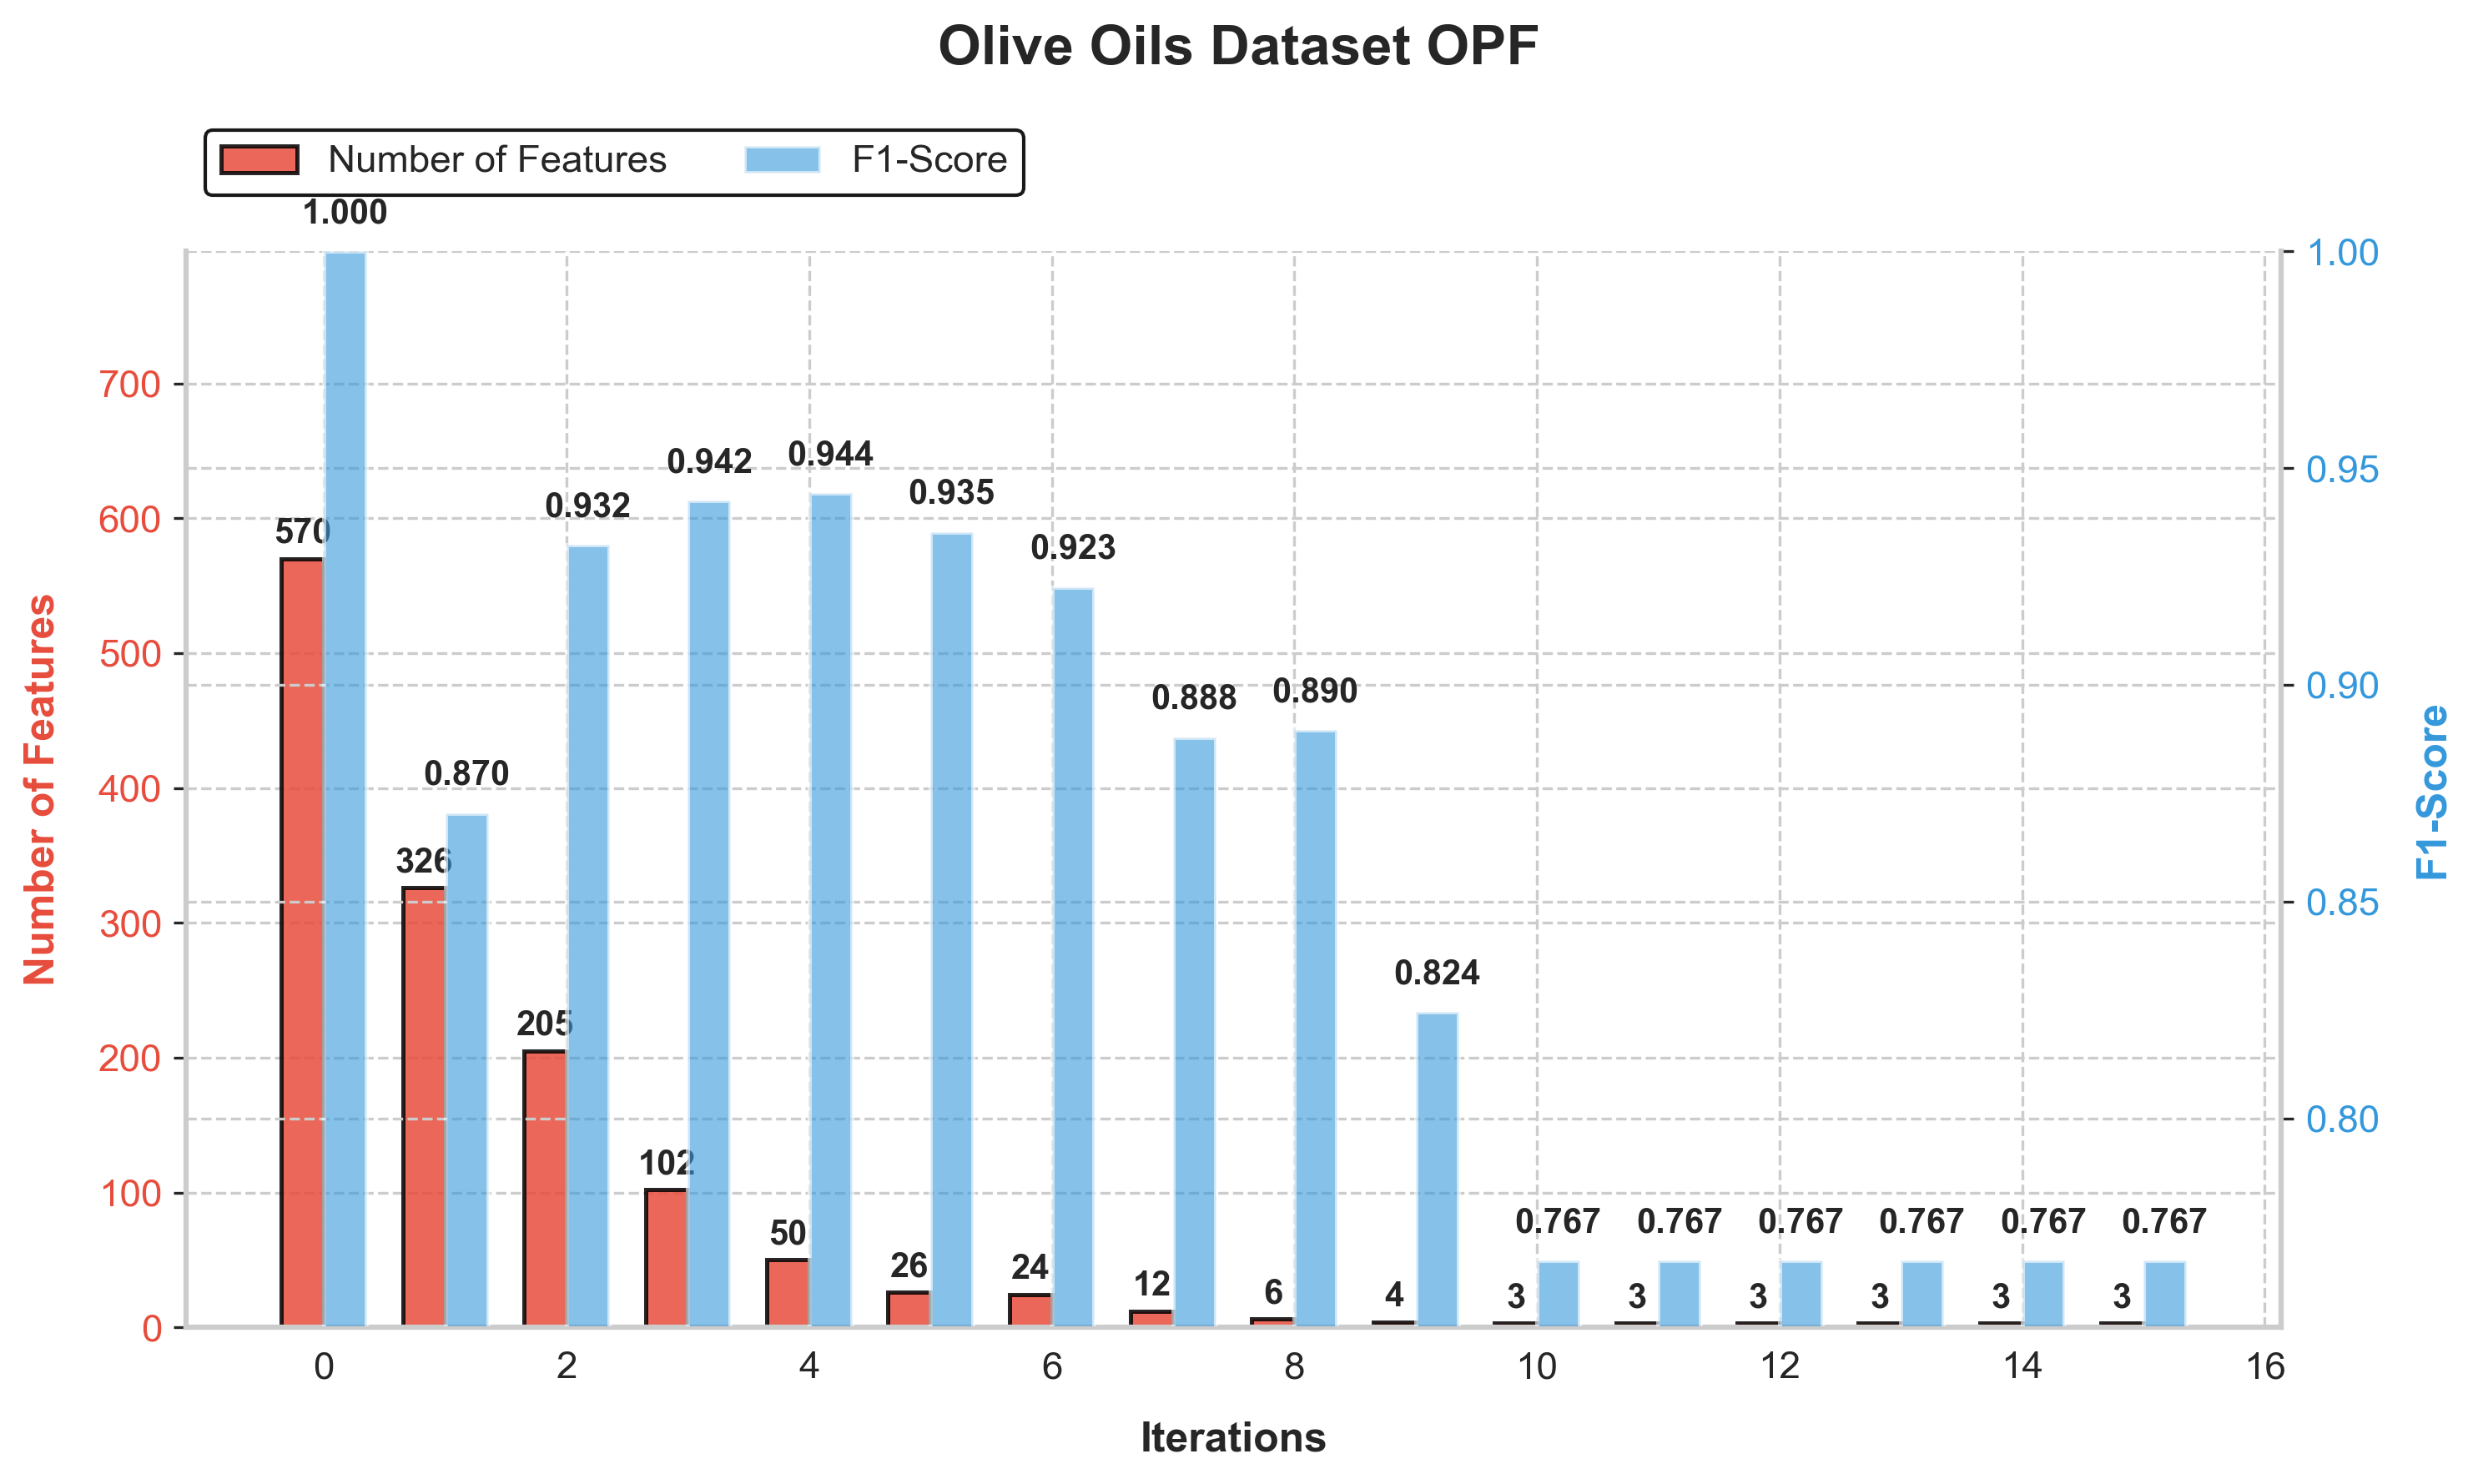

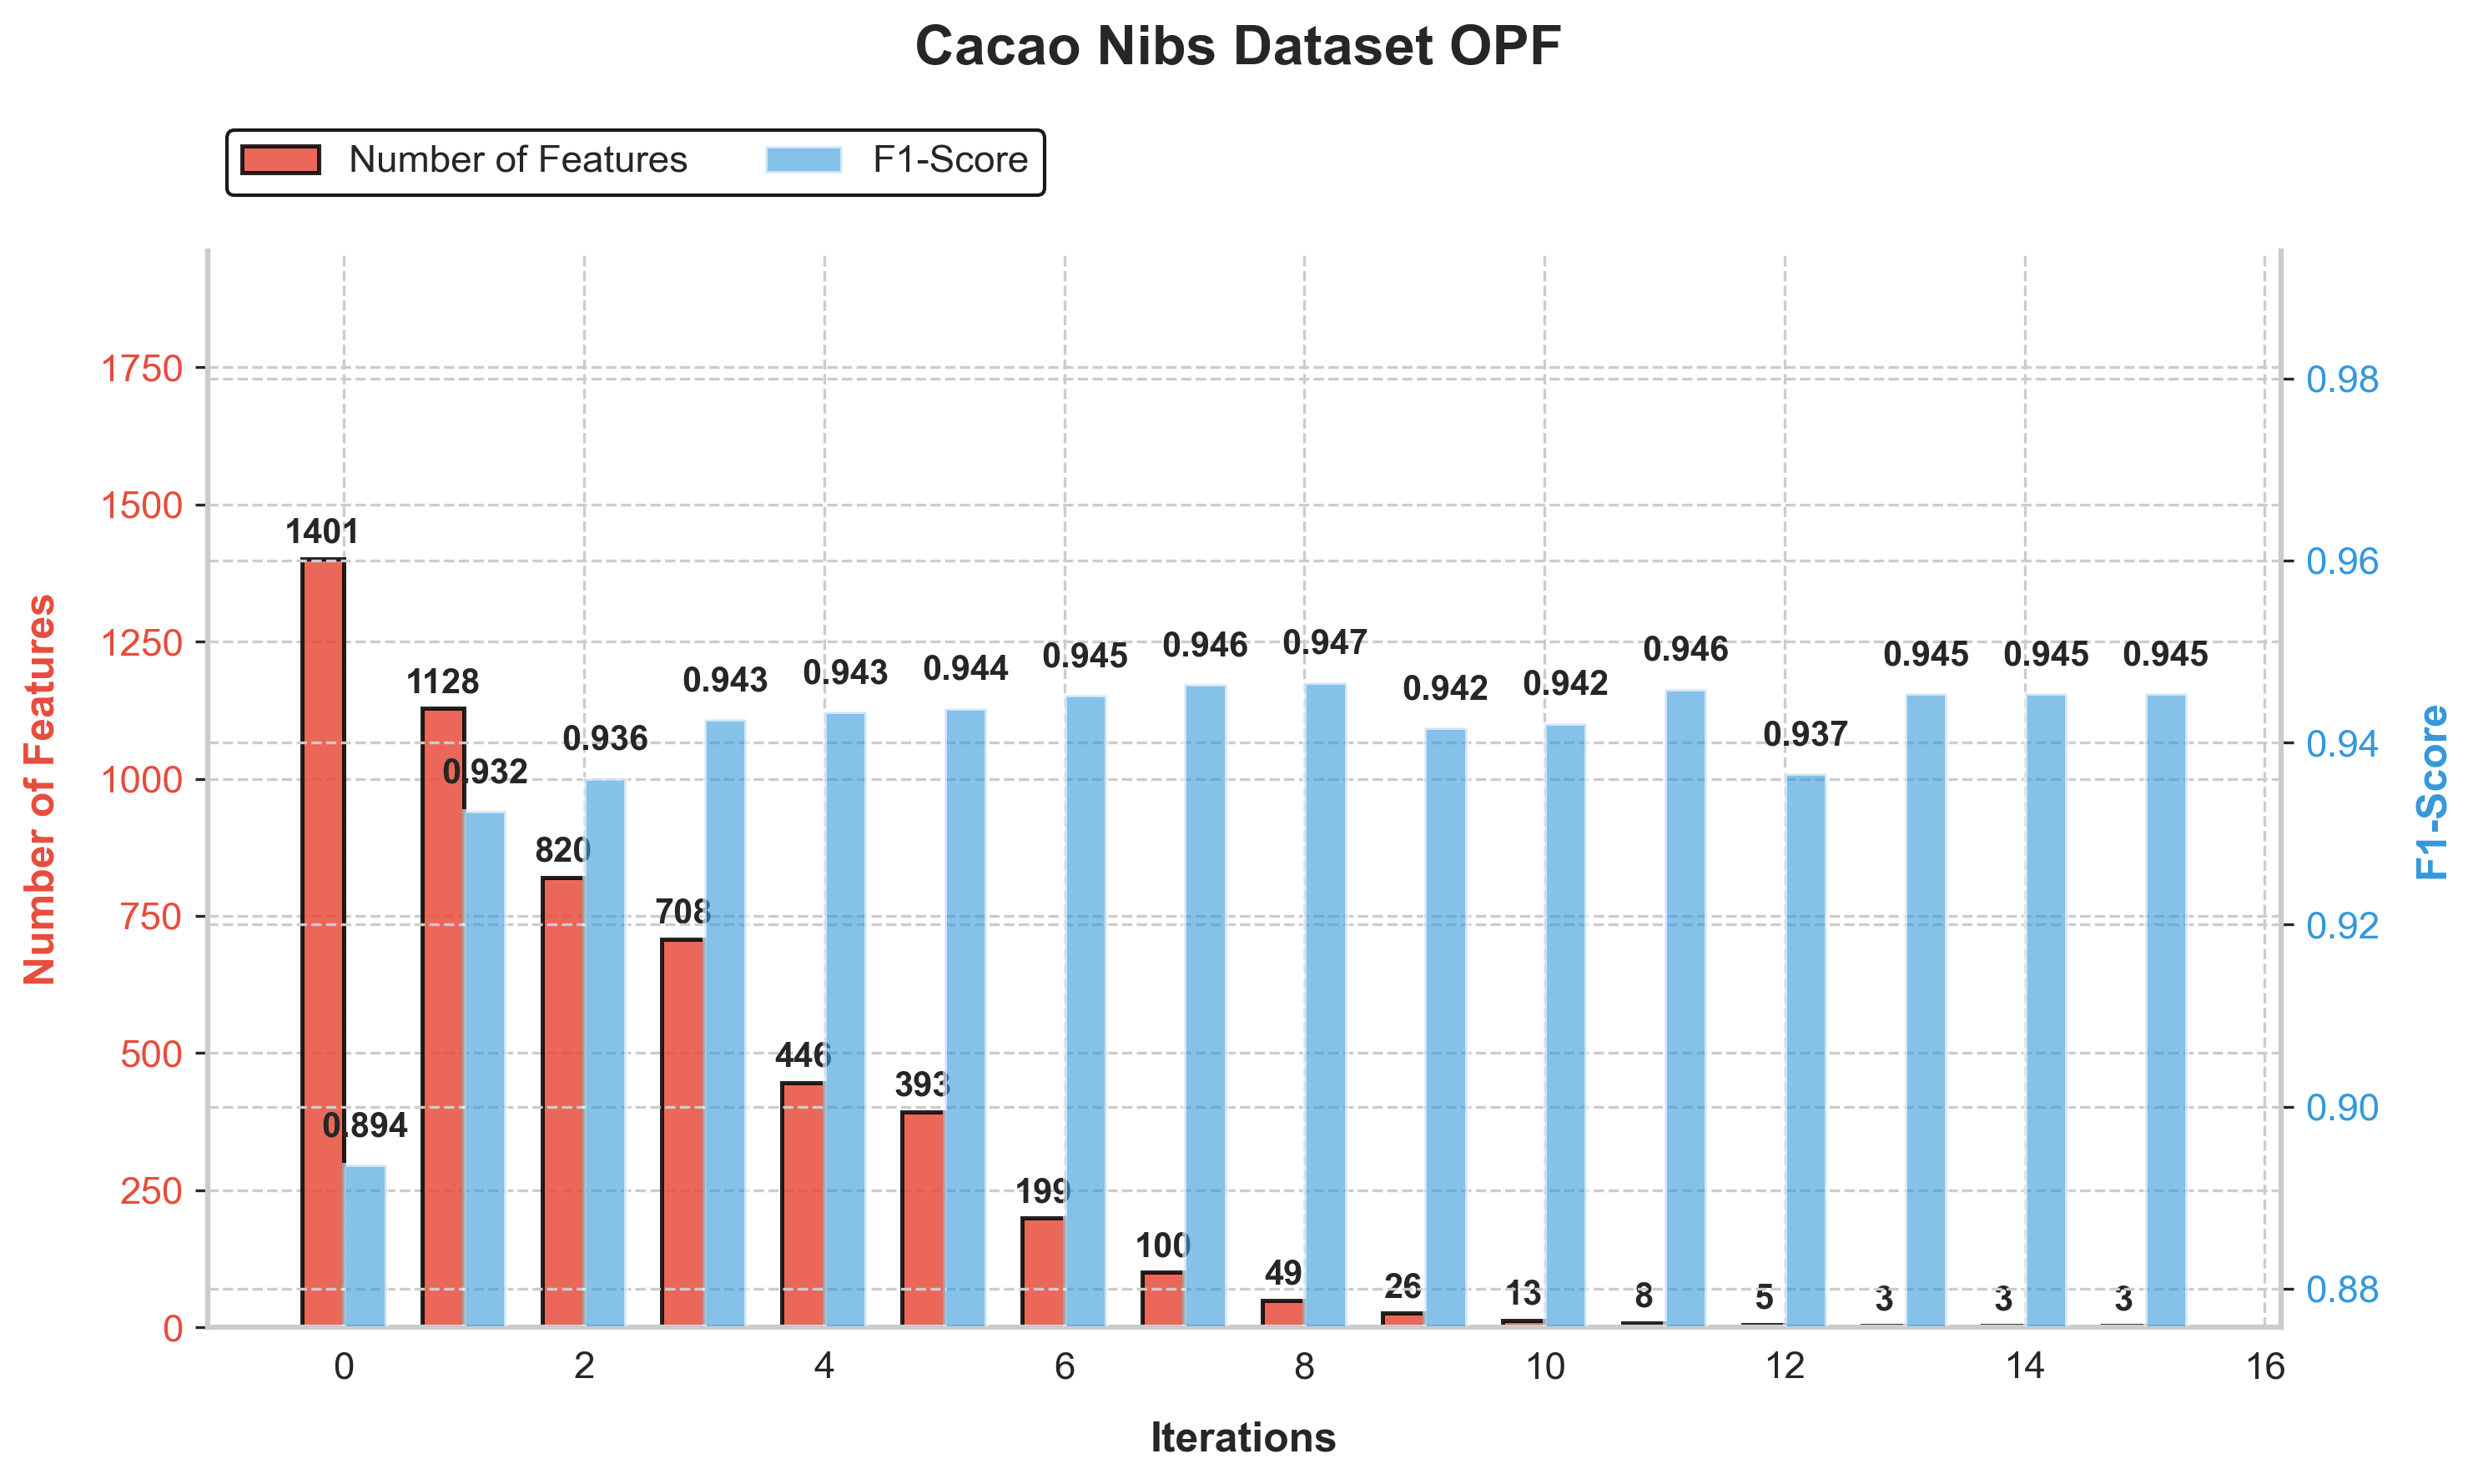

In [29]:

datasets = [[olive_x, y_olive, "Olive Oils Dataset OPF"],[df_x_cacao, y_cacao, "Cacao Nibs Dataset OPF"]]
best_features_datasets = {}

for X, y, name in datasets:
    start_time = time.time()
    final_f1, iterations, feature, score, best_features = evaluate_dataset(X, y, name)
   
    end_time = time.time()
    best_features_datasets[name] = best_features
   
    print(f"Processing time for {name}: {end_time - start_time:.2f} seconds")
    plot_results_for_covering_array(score, feature, iterations, f'../output_images/icafs_{name.replace(" ", "_").lower()}.png', dataset_name=name)

['Greece' 'Italy' 'Portugal' 'Spain']


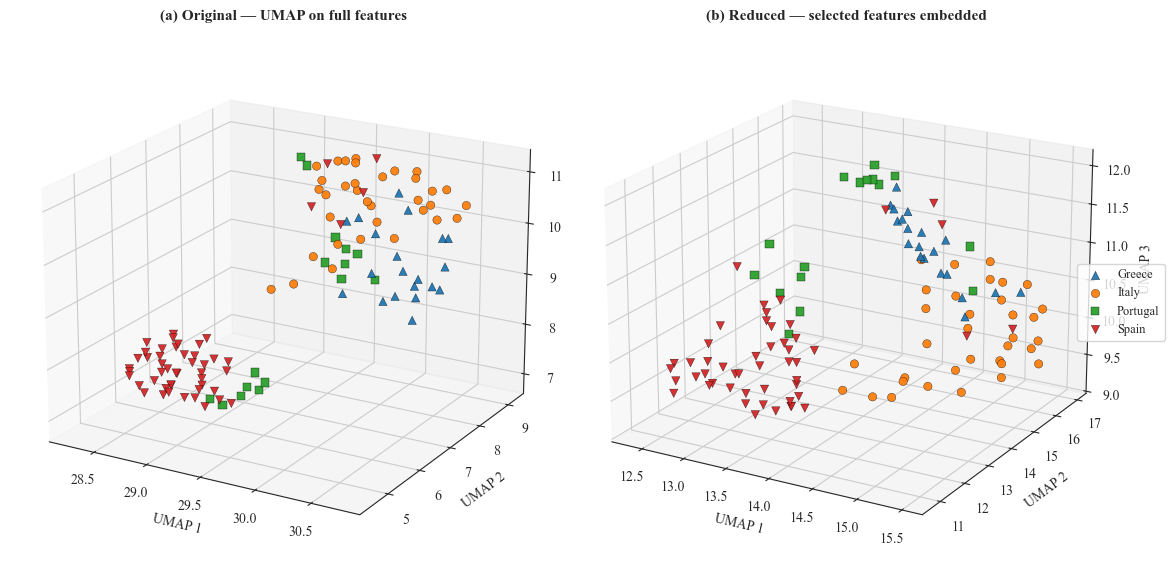

[1 2 3 4 5 6]


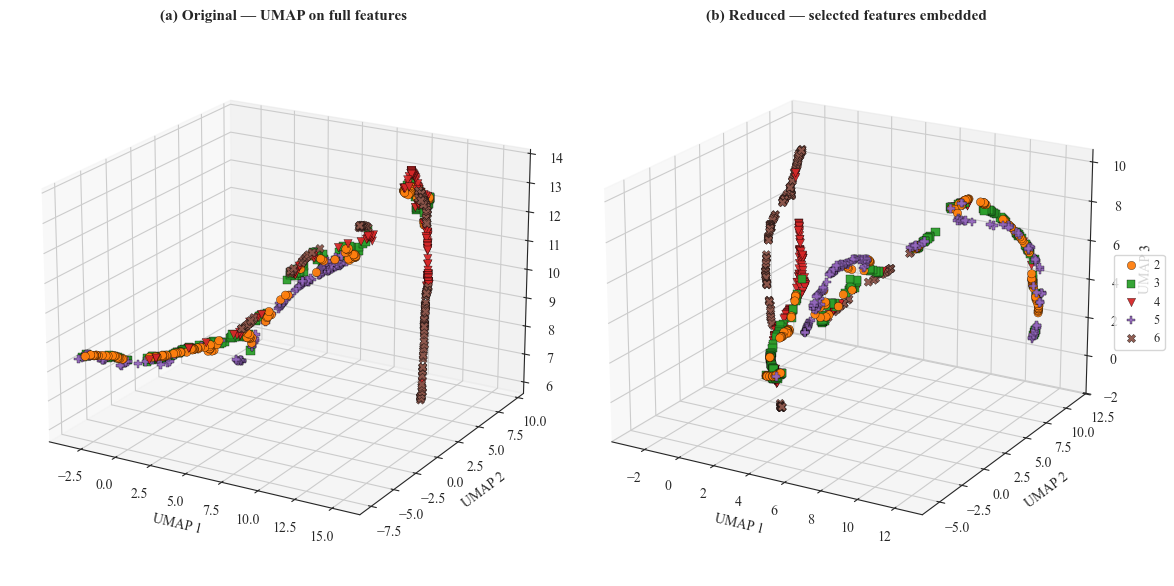

In [39]:
datasets = [[olive_x, y_olive, "Olive Oils Dataset OPF",unique_names_olive],[df_x_cacao, y_cacao, "Cacao Nibs Dataset OPF",unique_names_cacao]]
for X, y, name, unique_classes in datasets:
    best_features = best_features_datasets[name]
    print(unique_classes)
    save_path = f'../output_images/umap_{name.replace(" ","_").lower()}.png'
    plot_original_vs_reduced_umap(X.loc[:, best_features], X, y, unique_classes, dpi=300)